This notebook downloads and performs the FULL-SKY analysis on GW190521 data.

FULL-SKY considers a common reference time for both H1 and L1 data. (see paper for details).

We assume a ringdown model with 330+220 modes. 

We also calculate the $\ln\mathcal{B}^{330+220}_{220}$

In [1]:
import os

# jax device and parallelization flags on m4 mac.
# modify as needed.
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp

from myutils_corrected_2233 import Ntime, ACFs, set_detectors, set_detector_locations, cov_resp, initialize_det_locs
from myutils_corrected_2233 import ln_likelihood_full_jit

from scipy.linalg import toeplitz
import scipy.signal as sig

import lal
from gwpy.timeseries import TimeSeries
from other_utils import bandpass_ds, analysis_data, interp1d_jax, load_tables

jax.config.update("jax_enable_x64", True) 

/Users/kallol/Work/skyRing/examples/full-sky/../../src/myutils_corrected_2233.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data download parameters

This uses data downloaded directly from gwpy.

Set the parameters to download strain.

In [3]:
# Event data downloaded using gwpy.
# Starting at t_ref = t_peak + 6ms as reported in Capano et al. 

tgps = 1242442967.445 + 0.006 
seglen = 8 
fs = 16384 
fmin = 8 
fmax       = 1500
event_id = "GW190521" 
plot_checks = 0 
T = 0.2 
srate = 4096 

ra = 3.5    #right ascension
dec = 0.73  #declination


factor = 10
seed       = 31567
t0         = 0.0

qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l3/n1l3m3.dat"

Fetching strain data for H1 and L1

In [4]:
dH1 = TimeSeries.fetch_open_data('H1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)
dL1 = TimeSeries.fetch_open_data('L1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)

Calculate H1 and L1 starting times corresponding the reported sky locations (ra=3.5, dec=0.73). For FULL-SKY, common start time corresponds to the time in the detector that observes the merger later.

NOTE: We select a specific sky location to calculate tH1 to maintain consistency with FIXED-SKY

Calculate PSDs directly from the data.

In [5]:
n_analyze = Ntime(srate, T)

# Calculate H1 and L1 times
delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('H1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].location, ra, dec, tgps))
tH1 = tgps + dt_ifo

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('L1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].location, ra, dec, tgps))
tL1 = tgps + dt_ifo

print('H1 start time : ', onp.float64(tH1))
print('L1 start time : ', onp.float64(tL1))
if tH1>tL1:
    ref_det = 'H1'
    print('H1 peak appears later')
else:
    ref_det = 'L1'
    print('L1 peak appears later')


dH1_cond = bandpass_ds(dH1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)
dL1_cond = bandpass_ds(dL1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)

# Calculate PSDs

nperseg = int(seglen * (1/(dH1.times.value[1] - dH1.times.value[0])))
noverlap = nperseg // 2

psdH = sig.welch(
    dH1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",     
)

psdL = sig.welch(
    dL1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",     
)

H1 start time :  1242442967.4318974
L1 start time :  1242442967.4302728
H1 peak appears later


Set priors for the PE

In [6]:
# Prior limits
limits = [
    [150.0, 500.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [0., 1.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0, 6.28],
    [-1., 1.],
    [0, 3.14]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

Interpolating PSDs over freq range, setting up cov (using Cholesky decomposition) for TD likelihood

In [7]:
psdH = interp1d_jax(jnp.asarray(psdH[0],dtype=jnp.float64), jnp.asarray(psdH[1],dtype=jnp.float64))
psdL = interp1d_jax(jnp.asarray(psdL[0],dtype=jnp.float64), jnp.asarray(psdL[1],dtype=jnp.float64))

omega_22_r, omega_22_i, omega_33_r, omega_33_i = load_tables(qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

L_H, L_L, resp_H, resp_L = cov_resp(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
set_detectors(resp_H, resp_L)

rH, rL = initialize_det_locs()
set_detector_locations(rH, rL)

Set tH1 as the common start time for both H1 and L1. This is the data fed to the sampler for PE.

In [8]:
# data strain starting from tH1 in both H1 and L1 for the Full-sky analysis
dH1_analysis_data = analysis_data(dH1_cond[1], dH1_cond[0], tH1, n_analyze)
dL1_analysis_data = analysis_data(dL1_cond[1], dL1_cond[0], tH1, n_analyze)

h_H_t = dH1_analysis_data[1]
h_L_t = dL1_analysis_data[1]

Set up the numpyro model. Computes likelihood as a function of $\theta$

In [9]:
low  = jnp.asarray(low,  dtype=jnp.float64)   
high = jnp.asarray(high, dtype=jnp.float64)   

def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                   omega_22_r, omega_22_i, omega_33_r, omega_33_i,
                   T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_22_r=omega_22_r, omega_22_i=omega_22_i,
            omega_33_r=omega_33_r, omega_33_i=omega_33_i,
            T=T, srate=srate, t0=t0, ref_det=ref_det
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_22_r=omega_22_r, omega_22_i=omega_22_i,
    omega_33_r=omega_33_r, omega_33_i=omega_33_i,
    T=T, srate=srate, t0=t0
)

def model():
    theta = numpyro.sample("theta", dist.Uniform(low, high).to_event(1))
    numpyro.factor("loglike", loglik_fn(theta))

In [10]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns = NestedSampler(
    model,
    constructor_kwargs=dict(
        num_live_points=10000,  
        max_samples=500_000,    
        verbose=False,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,        
    ),
)
ns.run(rng_run)
ns.print_summary()
posterior = ns.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 38894349
samples: 205164
phantom samples: 0
likelihood evals / sample: 189.6
phantom fraction (%): 0.0%
--------
logZ=-823.821 +- 0.046
max(logL)=-804.077
H=-14.98
ESS=29151
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 317.0 +- 35.0 | 271.0 / 319.0 / 360.0 | 334.0 | 334.0
theta[1]: 0.81 +- 0.13 | 0.66 / 0.85 / 0.92 | 0.89 | 0.89
theta[2]: 0.7 +- 0.58 | 0.23 / 0.52 / 1.39 | 0.79 | 0.79
theta[3]: 3.4 +- 1.8 | 1.0 / 3.4 / 5.7 | 5.1 | 5.1
theta[4]: 0.13 +- 0.12 | 0.04 / 0.1 / 0.28 | 0.14 | 0.14
theta[5]: 3.0 +- 1.8 | 0.5 / 3.1 / 5.4 | 3.7 | 3.7
theta[6]: 0.01 +- 0.53 | -0.73 / 0.01 / 0.75 | 0.58 | 0.58
theta[7]: 3.9 +- 1.6 | 2.1 / 3.5 / 5.8 | 5.6 | 5.6
theta[8]: 0.03 +- 0.59 | -0.8 / 0.13 / 0.73 | 0.63 | 0.63
theta[9]: 1.49 +- 0.92 | 0.27 / 1.49 / 2.77 | 2.86 | 2.86
--------


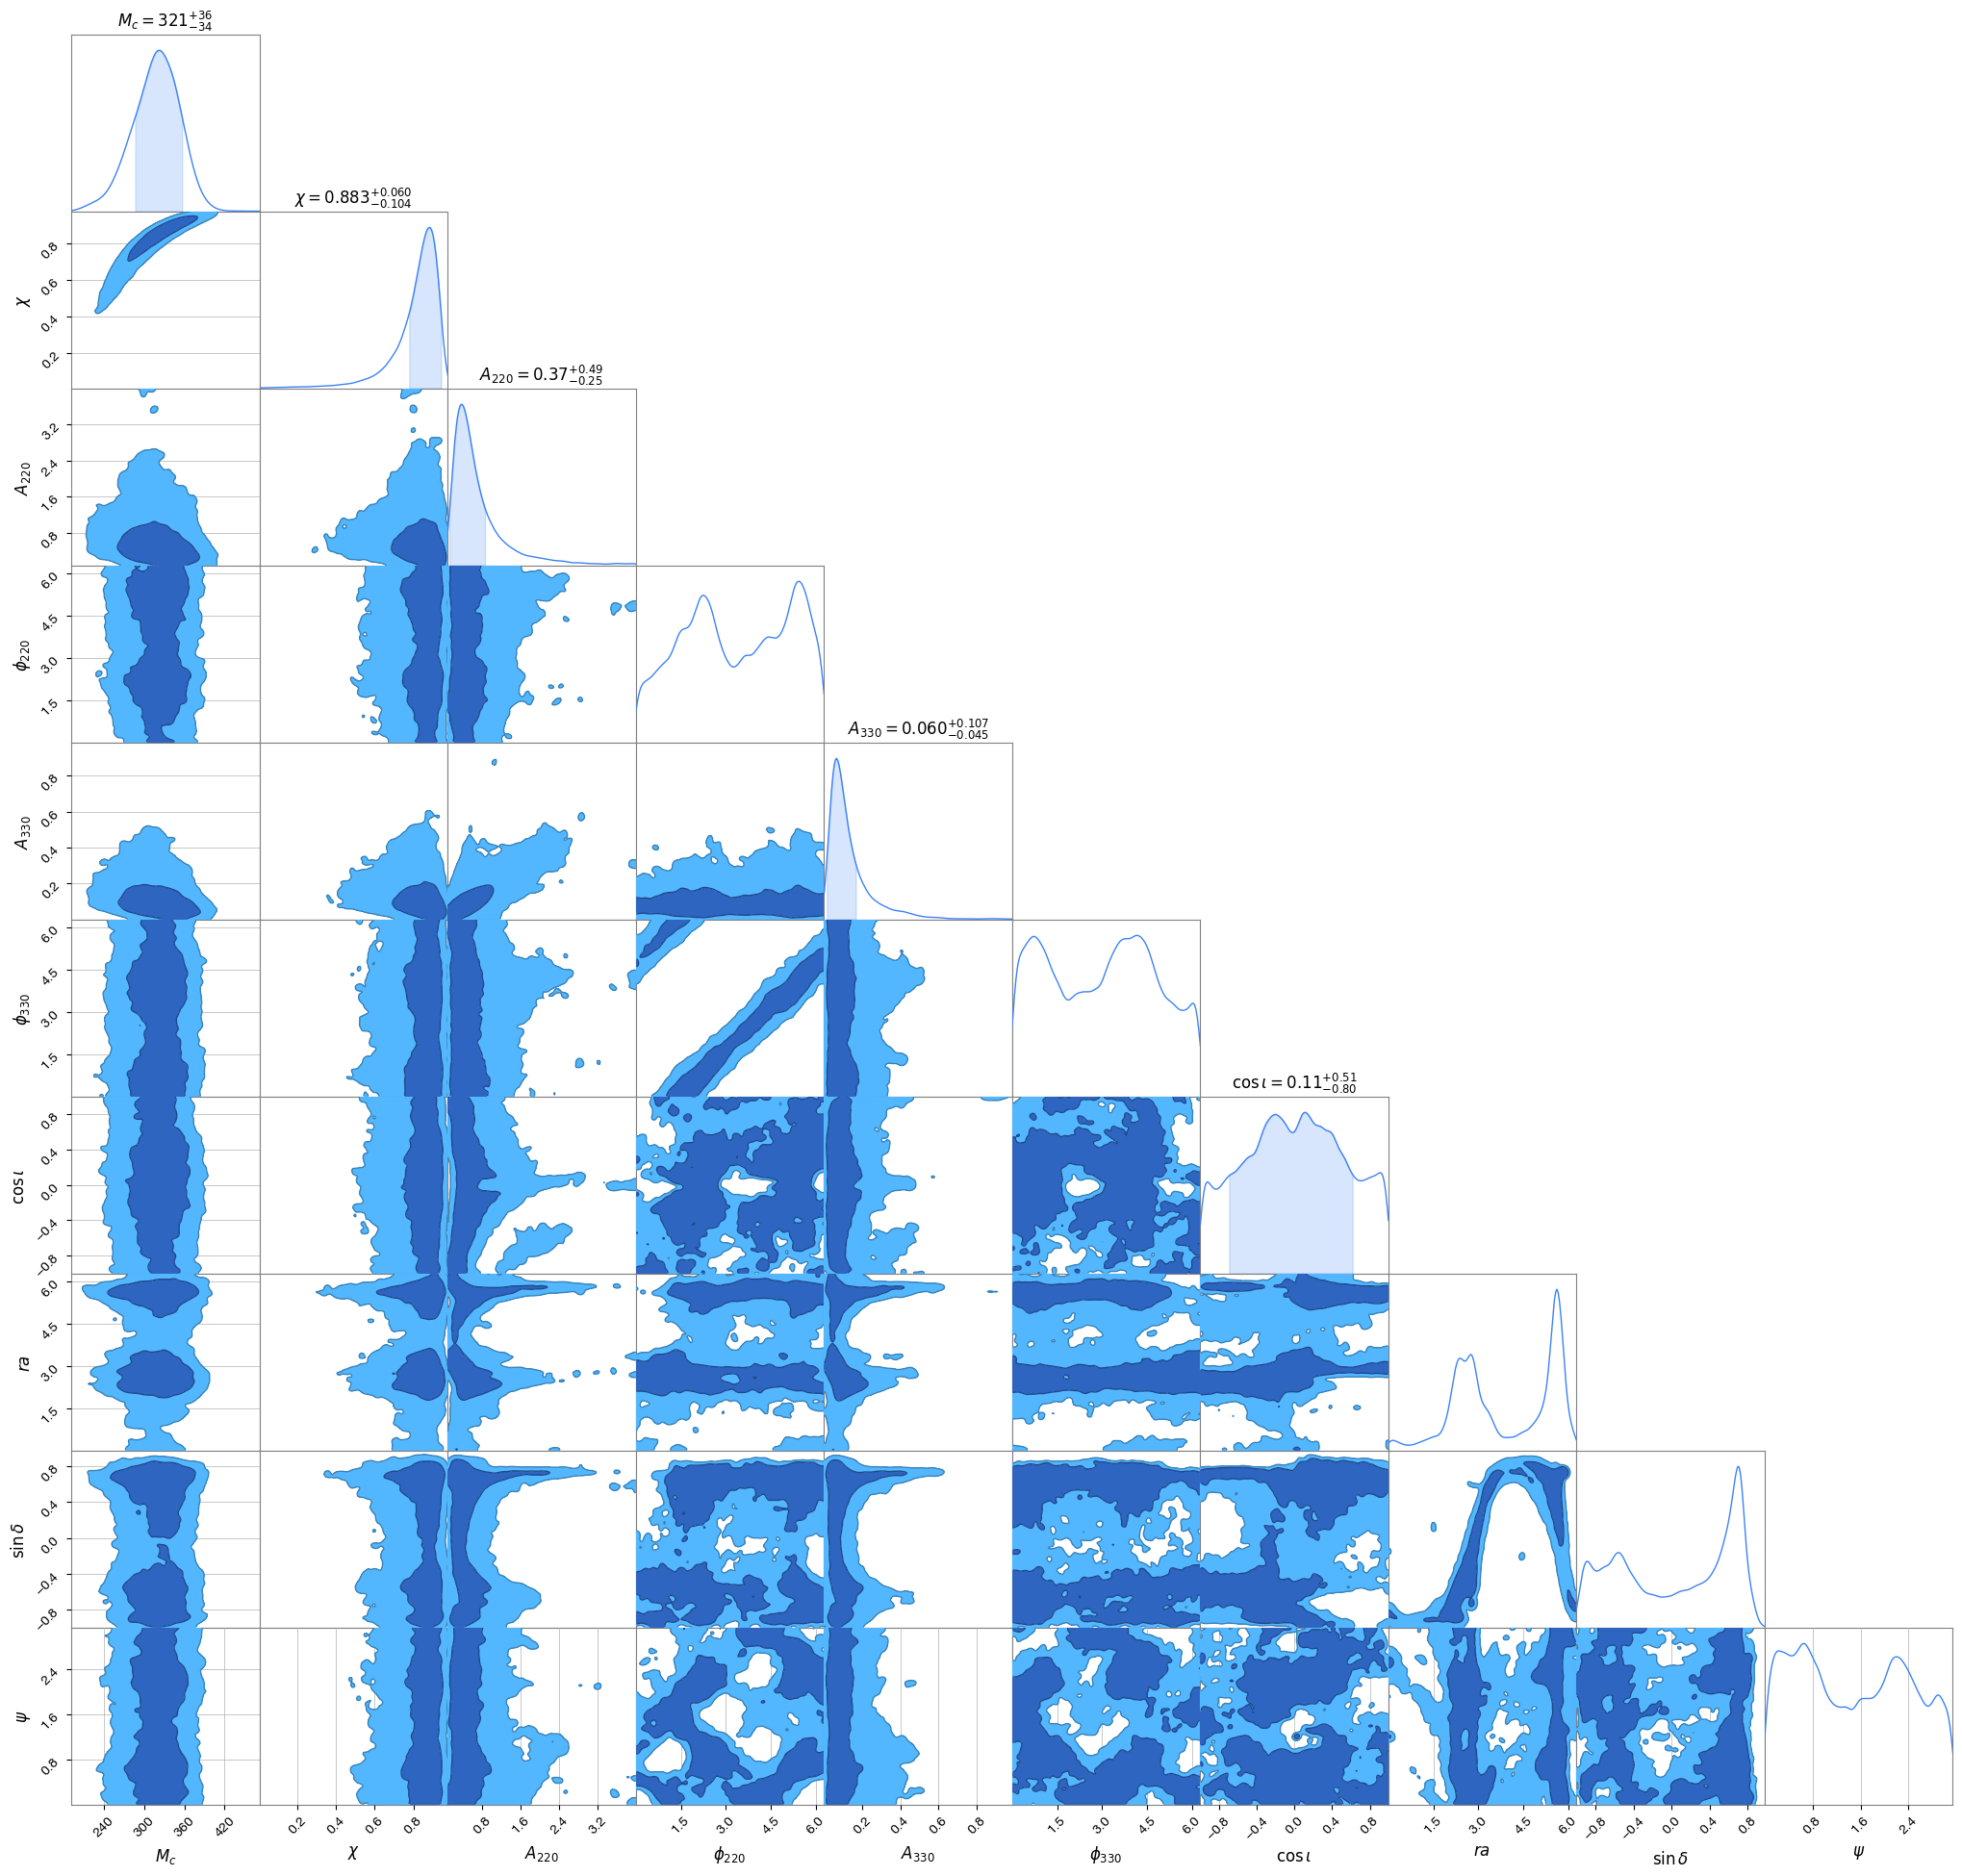

In [11]:
ns_parameters = [r'$M_c$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$ra$', r'$\sin \delta$', r'$\psi$']

df_ns = pd.DataFrame(posterior['theta'], columns=ns_parameters)
c = ChainConsumer()
c.add_chain(Chain(samples=df_ns, color='b', name="Full sky"))
c.set_override(ChainConfig(sigmas=[0, 1, 2]))
c.set_plot_config(
    PlotConfig(

        contour_label_font_size=24,
        legend_kwargs={'fontsize': 30}
    )
)
fig = c.plotter.plot()
# plt.savefig(corner_path, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
posterior_dir = '../posterior_files/full-sky/'
onp.save(posterior_dir + 'posterior.' + event_id + '.full-sky.npy', onp.asarray(posterior['theta']))

In [14]:
print('logZ (330+220) : ', ns._results.log_Z_mean)

logZ (330+220) :  -823.8208605935324


Now set overtone amplitude to 0 to invoke 220 only model and calculate $\ln\mathcal{B}^{330+220}_{220}$

In [15]:
# Set prior limits (no 330 mode)
limits = [
    [150.0, 500.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0, 6.28],
    [-1., 1.],
    [0, 3.14]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

Set up the numpyro sampler for 220 only model

In [16]:
low  = jnp.asarray(low,  dtype=jnp.float64)   
high = jnp.asarray(high, dtype=jnp.float64)  

def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                   omega_22_r, omega_22_i, omega_33_r, omega_33_i,
                   T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_22_r=omega_22_r, omega_22_i=omega_22_i,
            omega_33_r=omega_33_r, omega_33_i=omega_33_i,
            T=T, srate=srate, t0=t0, ref_det=ref_det
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_22_r=omega_22_r, omega_22_i=omega_22_i,
    omega_33_r=omega_33_r, omega_33_i=omega_33_i,
    T=T, srate=srate, t0=t0
)

def model_220():
    theta = numpyro.sample("theta", dist.Uniform(low, high).to_event(1))
    amp_phase_330 = jnp.array([0.0, 0.0])
    theta_ = jnp.concatenate(
                        [
                            theta[:4],
                            amp_phase_330,
                            theta[4:],
                        ],
                    )

    numpyro.factor("loglike", loglik_fn(theta_))

In [17]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns_220 = NestedSampler(
    model_220,
    constructor_kwargs=dict(
        num_live_points=10000,     
        max_samples=500_000,      
        verbose=False,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,               
    ),
)
ns_220.run(rng_run)
ns_220.print_summary()
posterior_220 = ns_220.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 27425799
samples: 175140
phantom samples: 0
likelihood evals / sample: 156.6
phantom fraction (%): 0.0%
--------
logZ=-824.905 +- 0.042
max(logL)=-809.588
H=-12.08
ESS=23555
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 340.0 +- 29.0 | 302.0 / 342.0 / 375.0 | 356.0 | 356.0
theta[1]: 0.885 +- 0.067 | 0.807 / 0.9 / 0.947 | 0.925 | 0.925
theta[2]: 0.45 +- 0.36 | 0.16 / 0.35 / 0.85 | 0.3 | 0.3
theta[3]: 3.3 +- 1.8 | 0.9 / 3.2 / 5.7 | 4.1 | 4.1
theta[4]: -0.01 +- 0.49 | -0.67 / -0.02 / 0.68 | -0.38 | -0.38
theta[5]: 3.6 +- 1.5 | 1.6 / 3.3 / 5.7 | 4.6 | 4.6
theta[6]: 0.07 +- 0.53 | -0.69 / 0.16 / 0.71 | 0.65 | 0.65
theta[7]: 1.51 +- 0.92 | 0.27 / 1.51 / 2.82 | 1.64 | 1.64
--------


In [18]:
print('logZ (220) : ', ns_220._results.log_Z_mean)

logZ (220) :  -824.9050704411914


In [20]:
ns._results.log_Z_mean - ns_220._results.log_Z_mean

Array(1.08420985, dtype=float64)